In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
w   = np.array([4.0894e-1, 4.9890e-3, 1.3264e-3,
                2.9550e-4, 2.2260e-5, 1.5048e-6])
rho = np.array([1.0, 0.9999999, 0.9999992,
                0.9999545, 0.9989710, 0.9975553])

In [3]:
sigma1_sq = 1.5511e-2

In [4]:
def compute_gamma(w_sub, rho_sub):
    rho_aug = np.append(rho_sub, 0)
    terms = np.sqrt(w_sub/w_sub[0] *
                   (rho_aug[:-1]**2 - rho_aug[1:]**2))
    return terms.sum()**2

In [5]:
idx = [0, 1, 4]
gamma = compute_gamma(w[idx], rho[idx])
print(f'gamma = {gamma:.6f}')

gamma = 0.000165


In [6]:
# theoratical MSE function
def mse_mc(p,sigma1_sq,w1):
    return sigma1_sq * w1/p

def mse_mfmc(p, w_sub, rho_sub, sigma1_sq):
    """
    MFMC: MSE from Corollary 3.5 eq.(3.19)
    MSE = sigma1^2 / p * (sum sqrt(wi*(rho_i^2-rho_{i+1}^2)))^2
    """
    rho_aug = np.append(rho_sub, 0)
    # r_i* from eq.(3.14)
    r_star = np.sqrt(
        w_sub[0] * (rho_aug[:-1]**2 - rho_aug[1:]**2)
        / (w_sub * (1 - rho_sub[1]**2))
    )
    m1_star = p / (w_sub @ r_star)
    # MSE from eq.(3.19)
    return sigma1_sq * (1 - rho_sub[1]**2) * p \
           / (m1_star**2 * w_sub[0])

In [7]:
budgets = np.logspace(-4, 4, 200)
# 1. plain MC (HF only)
mse_hf = [mse_mc(p, sigma1_sq, w[0]) for p in budgets]
#MFMC with 2 models
mse_2mdl =[mse_mfmc(p,w[[0,1]],rho[[0,1]],sigma1_sq) for p in budgets]
# 3. MFMC with 3 models: f1, f2, f5
mse_3mdl = [mse_mfmc(p, w[[0,1,4]], rho[[0,1,4]], sigma1_sq)
             for p in budgets]
# 4. MFMC with 6 models: f1,...,f6
mse_6mdl = [mse_mfmc(p, w, rho, sigma1_sq)
             for p in budgets]

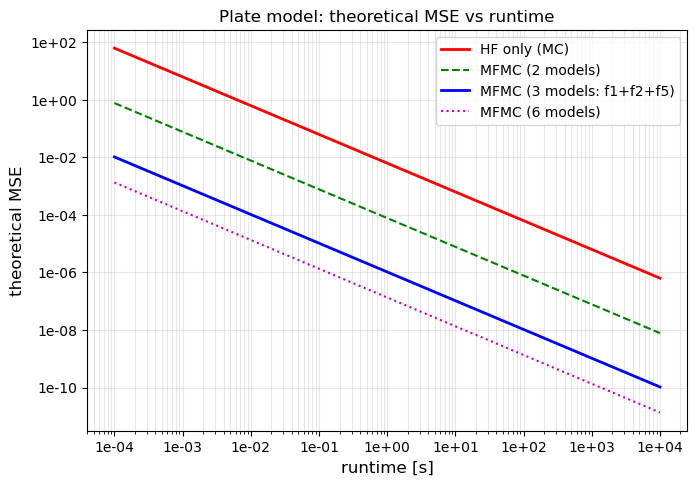

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.loglog(budgets, mse_hf,   'r-',  linewidth=2,
          label='HF only (MC)')
ax.loglog(budgets, mse_2mdl, 'g--', linewidth=1.5,
          label='MFMC (2 models)')
ax.loglog(budgets, mse_3mdl, 'b-',  linewidth=2,
          label='MFMC (3 models: f1+f2+f5)')
ax.loglog(budgets, mse_6mdl, 'm:',  linewidth=1.5,
          label='MFMC (6 models)')

ax.set_xlabel('runtime [s]', fontsize=12)
ax.set_ylabel('theoretical MSE', fontsize=12)
ax.set_title('Plate model: theoretical MSE vs runtime',
             fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x:.0e}'))
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x:.0e}'))
plt.show()

In [9]:
def compute_gamma(w_sub, rho_sub):
    rho_aug = np.append(rho_sub, 0)
    terms = np.sqrt(w_sub/w_sub[0] *
                   (rho_aug[:-1]**2 - rho_aug[1:]**2))
    return terms.sum()**2

print('gamma values:')
print(f'  2 models: {compute_gamma(w[[0,1]], rho[[0,1]]):.2e}')
print(f'  3 models: {compute_gamma(w[[0,1,4]], rho[[0,1,4]]):.2e}')
print(f'  6 models: {compute_gamma(w, rho):.2e}')

gamma values:
  2 models: 1.23e-02
  3 models: 1.65e-04
  6 models: 2.13e-05


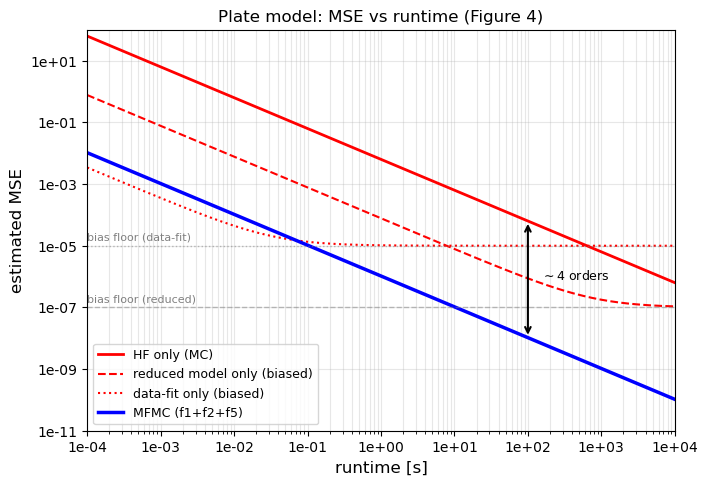

Speedup vs plain MC:
  2 models: 81x
  3 models: 6061x
  6 models: 46948x


In [10]:
sigma2_sq  = sigma1_sq * 0.9999999**2  # ≈ sigma1_sq
bias2_sq   = 1e-7   # read from original Figure 4
mse_f2only = np.array([sigma2_sq * w[1] / p + bias2_sq
                        for p in budgets])

# data-fit model f5: lower correlation
# bias floor ≈ 1e-5 from Figure 4
sigma5_sq  = sigma1_sq * 0.9989710**2
bias5_sq   = 1e-5
mse_f5only = np.array([sigma5_sq * w[4] / p + bias5_sq
                        for p in budgets])

fig, ax = plt.subplots(figsize=(7, 5))

ax.loglog(budgets, mse_hf,   'r-',
          lw=2, label='HF only (MC)')
ax.loglog(budgets, mse_f2only, 'r--',
          lw=1.5, label='reduced model only (biased)')
ax.loglog(budgets, mse_f5only, 'r:',
          lw=1.5, label='data-fit only (biased)')
ax.loglog(budgets, mse_3mdl, 'b-',
          lw=2.5, label='MFMC (f1+f2+f5)')


ax.axhline(y=bias2_sq, color='gray', linestyle='--',
           alpha=0.5, lw=1)
ax.axhline(y=bias5_sq, color='gray', linestyle=':',
           alpha=0.5, lw=1)
ax.text(1e-4, bias2_sq*1.5, 'bias floor (reduced)',
        fontsize=8, color='gray')
ax.text(1e-4, bias5_sq*1.5, 'bias floor (data-fit)',
        fontsize=8, color='gray')


p_ref = 1e2
mse_hf_ref   = mse_mc(p_ref, sigma1_sq, w[0])
mse_mfmc_ref = mse_mfmc(p_ref, w[[0,1,4]],
                         rho[[0,1,4]], sigma1_sq)
ax.annotate('', xy=(p_ref, mse_mfmc_ref),
            xytext=(p_ref, mse_hf_ref),
            arrowprops=dict(arrowstyle='<->',
                           color='black', lw=1.5))
ax.text(p_ref*1.5, np.sqrt(mse_hf_ref*mse_mfmc_ref),
        r'$\sim 4$ orders', fontsize=9)

ax.set_xlabel('runtime [s]', fontsize=12)
ax.set_ylabel('estimated MSE', fontsize=12)
ax.set_title('Plate model: MSE vs runtime (Figure 4)',
             fontsize=12)
ax.legend(fontsize=9, loc='lower left')
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim([1e-4, 1e4])
ax.set_ylim([1e-11, 1e2])

plt.tight_layout()
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x:.0e}'))
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x:.0e}'))
plt.show()


print('Speedup vs plain MC:')
print(f'  2 models: {1/1.23e-2:.0f}x')
print(f'  3 models: {1/1.65e-4:.0f}x')
print(f'  6 models: {1/2.13e-5:.0f}x')